# Design Challenge 2 - Tasks 4.1-4.2

This notebook is tailored for the EEMEM0018 IoT System Prototyping coursework.

It covers:
- `4.1 Baseline (Not Assessed)`
- `4.2 Architecture Exploration`

For group `15`, the personalised digits for the later task `4.3` will be `5` and `6`, but this notebook intentionally focuses only on the shared baseline dataset for now.


## What This Notebook Does

1. Runs the baseline Magic Wand digit workflow on the provided digit dataset.
2. Keeps the dataset split ratio unchanged.
3. Trains multiple CNN architectures.
4. Records for each architecture:
   - PC-side test accuracy
   - PC-side quantized TFLite test accuracy
   - Quantized TFLite model size
5. Plots `accuracy vs model size`.
6. Exports `.keras`, `.tflite`, and `.cc` models for later Arduino latency testing.


In [1]:
%tensorflow_version 2.x

import os
import math
import glob
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
from IPython.display import display, Image
from google.colab import files

!apt-get update -qq
!apt-get install -y -qq xxd


Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [2]:
GROUP_ID = 15
PERSONAL_DIGITS = [GROUP_ID % 10, (GROUP_ID % 10) + 1]
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('GROUP_ID =', GROUP_ID)
print('Digits reserved for task 4.3 =', PERSONAL_DIGITS)


GROUP_ID = 15
Digits reserved for task 4.3 = [5, 6]


In [3]:
WORK_DIR = Path('/content/dc2_4_1_4_2')
MODELS_DIR = WORK_DIR / 'models'
DATASET_DIR = WORK_DIR / 'dataset'
TRAIN_DIR = DATASET_DIR / 'train'
VAL_DIR = DATASET_DIR / 'validation'
TEST_DIR = DATASET_DIR / 'test'
CHKPT_DIR = WORK_DIR / 'checkpoints'
RESULTS_DIR = WORK_DIR / 'results'

for path in [WORK_DIR, MODELS_DIR, DATASET_DIR, CHKPT_DIR, RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TEST_PERCENTAGE = 10
VALIDATION_PERCENTAGE = 30
TRAIN_PERCENTAGE = 100 - (TEST_PERCENTAGE + VALIDATION_PERCENTAGE)

IMAGE_WIDTH = 32
IMAGE_HEIGHT = 32
BATCH_SIZE = 32
EPOCHS = 20
SCORE_THRESHOLD = 0.75

print('Dataset split preserved from baseline:')
print('Train:', TRAIN_PERCENTAGE, 'Validation:', VALIDATION_PERCENTAGE, 'Test:', TEST_PERCENTAGE)


Dataset split preserved from baseline:
Train: 60 Validation: 30 Test: 10


## 4.1 Baseline Dataset

The coursework PDF says the baseline is **not assessed**, but it must be run successfully before the assessed tasks.

This notebook uses the same digit dataset source as the provided baseline notebook.


In [4]:
%cd /content
!rm -rf magic_wand_digit_data-* magic_wand_digit_data.zip
!curl -L https://github.com/petewarden/magic_wand_digit_data/archive/8170591863f9addca27b1a963263f7c7bed33f41.zip -o magic_wand_digit_data.zip
!unzip -qq -o magic_wand_digit_data.zip
!rm -rf {DATASET_DIR}
!mkdir -p {DATASET_DIR}
!mv magic_wand_digit_data-*/* {DATASET_DIR}
!rm -rf magic_wand_digit_data-* magic_wand_digit_data.zip

print('Baseline dataset downloaded to:', DATASET_DIR)


/content
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  238k    0  238k    0     0   427k      0 --:--:-- --:--:-- --:--:-- 3828k
Baseline dataset downloaded to: /content/dc2_4_1_4_2/dataset


In [5]:
dataset_jsons = str(DATASET_DIR / '*.json')
strokes = []

for filename in sorted(glob.glob(dataset_jsons)):
    with open(filename, 'r') as file:
        file_data = json.load(file)
    for stroke in file_data['strokes']:
        stroke['filename'] = filename
        strokes.append(stroke)

labels_in_source = sorted({stroke['label'].lower() for stroke in strokes if stroke['label']})
NUM_GESTURES = len(labels_in_source)

print('JSON files pattern:', dataset_jsons)
print('Total strokes:', len(strokes))
print('Labels:', labels_in_source)
print('NUM_GESTURES =', NUM_GESTURES)


JSON files pattern: /content/dc2_4_1_4_2/dataset/*.json
Total strokes: 1000
Labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
NUM_GESTURES = 10


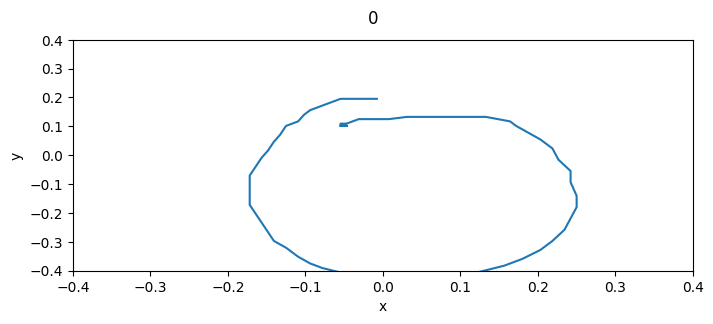

In [6]:
def plot_stroke(stroke):
    x_array = [coords['x'] for coords in stroke['strokePoints']]
    y_array = [coords['y'] for coords in stroke['strokePoints']]

    fig = plt.figure(figsize=(8, 3))
    fig.suptitle(stroke['label'])
    ax = fig.add_subplot(111)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(-0.4, 0.4)
    ax.set_ylim(-0.4, 0.4)
    ax.plot(x_array, y_array)
    plt.show()

plot_stroke(strokes[0])


## Pre-processing

The rasterization and augmentation logic below follows the baseline Magic Wand workflow so that comparisons remain fair.


In [7]:
FIXED_POINT = 256


def mul_fp(a, b):
    return (a * b) / FIXED_POINT


def div_fp(a, b):
    if b == 0:
        b = 1
    return (a * FIXED_POINT) / b


def float_to_fp(a):
    return math.floor(a * FIXED_POINT)


def norm_to_coord_fp(a, range_fp, half_size_fp):
    a_fp = float_to_fp(a)
    norm_fp = div_fp(a_fp, range_fp)
    return mul_fp(norm_fp, half_size_fp) + half_size_fp


def round_fp_to_int(a):
    return math.floor((a + (FIXED_POINT / 2)) / FIXED_POINT)


def gate(a, min_value, max_value):
    if a < min_value:
        return min_value
    elif a > max_value:
        return max_value
    else:
        return a


def rasterize_stroke(stroke_points, x_range, y_range, width, height):
    num_channels = 3
    buffer_byte_count = height * width * num_channels
    buffer = bytearray(buffer_byte_count)

    width_fp = width * FIXED_POINT
    height_fp = height * FIXED_POINT
    half_width_fp = width_fp / 2
    half_height_fp = height_fp / 2
    x_range_fp = float_to_fp(x_range)
    y_range_fp = float_to_fp(y_range)

    t_inc_fp = FIXED_POINT / len(stroke_points)
    one_half_fp = FIXED_POINT / 2

    for point_index in range(len(stroke_points) - 1):
        start_point = stroke_points[point_index]
        end_point = stroke_points[point_index + 1]
        start_x_fp = norm_to_coord_fp(start_point['x'], x_range_fp, half_width_fp)
        start_y_fp = norm_to_coord_fp(-start_point['y'], y_range_fp, half_height_fp)
        end_x_fp = norm_to_coord_fp(end_point['x'], x_range_fp, half_width_fp)
        end_y_fp = norm_to_coord_fp(-end_point['y'], y_range_fp, half_height_fp)
        delta_x_fp = end_x_fp - start_x_fp
        delta_y_fp = end_y_fp - start_y_fp

        t_fp = point_index * t_inc_fp
        if t_fp < one_half_fp:
            local_t_fp = div_fp(t_fp, one_half_fp)
            one_minus_t_fp = FIXED_POINT - local_t_fp
            red = round_fp_to_int(one_minus_t_fp * 255)
            green = round_fp_to_int(local_t_fp * 255)
            blue = 0
        else:
            local_t_fp = div_fp(t_fp - one_half_fp, one_half_fp)
            one_minus_t_fp = FIXED_POINT - local_t_fp
            red = 0
            green = round_fp_to_int(one_minus_t_fp * 255)
            blue = round_fp_to_int(local_t_fp * 255)
        red = gate(red, 0, 255)
        green = gate(green, 0, 255)
        blue = gate(blue, 0, 255)

        if abs(delta_x_fp) > abs(delta_y_fp):
            line_length = abs(round_fp_to_int(delta_x_fp))
            if delta_x_fp > 0:
                x_inc_fp = 1 * FIXED_POINT
                y_inc_fp = div_fp(delta_y_fp, delta_x_fp)
            else:
                x_inc_fp = -1 * FIXED_POINT
                y_inc_fp = -div_fp(delta_y_fp, delta_x_fp)
        else:
            line_length = abs(round_fp_to_int(delta_y_fp))
            if delta_y_fp > 0:
                y_inc_fp = 1 * FIXED_POINT
                x_inc_fp = div_fp(delta_x_fp, delta_y_fp)
            else:
                y_inc_fp = -1 * FIXED_POINT
                x_inc_fp = -div_fp(delta_x_fp, delta_y_fp)

        for i in range(line_length + 1):
            x_fp = start_x_fp + (i * x_inc_fp)
            y_fp = start_y_fp + (i * y_inc_fp)
            x = round_fp_to_int(x_fp)
            y = round_fp_to_int(y_fp)
            if (x < 0) or (x >= width) or (y < 0) or (y >= height):
                continue
            buffer_index = (y * width * num_channels) + (x * num_channels)
            buffer[buffer_index + 0] = red
            buffer[buffer_index + 1] = green
            buffer[buffer_index + 2] = blue

    np_buffer = np.frombuffer(buffer, dtype=np.uint8).reshape(height, width, num_channels)
    return np_buffer


X_RANGE = 0.6
Y_RANGE = 0.6


def ensure_empty_dir(dirname):
    dirpath = Path(dirname)
    if dirpath.exists() and dirpath.is_dir():
        shutil.rmtree(dirpath)
    dirpath.mkdir(parents=True, exist_ok=True)


def augment_points(points, move_range, scale_range, rotate_range):
    move_x = np.random.uniform(low=-move_range, high=move_range)
    move_y = np.random.uniform(low=-move_range, high=move_range)
    scale = np.random.uniform(low=1.0 - scale_range, high=1.0 + scale_range)
    rotate = np.random.uniform(low=-rotate_range, high=rotate_range)

    x_axis_x = math.cos(rotate) * scale
    x_axis_y = math.sin(rotate) * scale
    y_axis_x = -math.sin(rotate) * scale
    y_axis_y = math.cos(rotate) * scale

    new_points = []
    for point in points:
        old_x = point['x']
        old_y = point['y']
        new_x = (x_axis_x * old_x) + (x_axis_y * old_y) + move_x
        new_y = (y_axis_x * old_x) + (y_axis_y * old_y) + move_y
        new_points.append({'x': new_x, 'y': new_y})

    return new_points


def save_strokes_as_images(strokes_subset, root_folder, width, height, augment_count):
    ensure_empty_dir(root_folder)
    labels = set()
    for stroke in strokes_subset:
        labels.add(stroke['label'].lower())
    for label in labels:
        label_path = Path(root_folder, label)
        ensure_empty_dir(label_path)

    label_counts = {}
    for stroke in strokes_subset:
        points = stroke['strokePoints']
        label = stroke['label'].lower()
        if label == '':
            raise Exception('Missing label for %s:%d' % (stroke['filename'], stroke['index']))
        if label not in label_counts:
            label_counts[label] = 0
        label_count = label_counts[label]
        label_counts[label] += 1
        raster = rasterize_stroke(points, X_RANGE, Y_RANGE, width, height)
        image = PIL.Image.fromarray(raster)
        image.save(Path(root_folder, label, str(label_count) + '.png'))
        for i in range(augment_count):
            augmented_points = augment_points(points, 0.1, 0.1, 0.3)
            raster = rasterize_stroke(augmented_points, X_RANGE, Y_RANGE, width, height)
            image = PIL.Image.fromarray(raster)
            image.save(Path(root_folder, label, str(label_count) + '_a' + str(i) + '.png'))
    return labels


In [8]:
shuffled_strokes = strokes
np.random.shuffle(shuffled_strokes)

test_count = math.floor((len(shuffled_strokes) * TEST_PERCENTAGE) / 100)
validation_count = math.floor((len(shuffled_strokes) * VALIDATION_PERCENTAGE) / 100)

test_strokes = shuffled_strokes[0:test_count]
validation_strokes = shuffled_strokes[test_count:(test_count + validation_count)]
train_strokes = shuffled_strokes[(test_count + validation_count):]

labels_test = save_strokes_as_images(test_strokes, TEST_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)
labels_val = save_strokes_as_images(validation_strokes, VAL_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)
labels_train = save_strokes_as_images(train_strokes, TRAIN_DIR, IMAGE_WIDTH, IMAGE_HEIGHT, NUM_GESTURES)

labels = sorted(labels_test.union(labels_val).union(labels_train))
label_to_int = {label: idx for idx, label in enumerate(labels)}
int_to_label = {idx: label for label, idx in label_to_int.items()}

print('Train strokes:', len(train_strokes))
print('Validation strokes:', len(validation_strokes))
print('Test strokes:', len(test_strokes))
print('Label order used by the network:', int_to_label)


Train strokes: 600
Validation strokes: 300
Test strokes: 100
Label order used by the network: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [9]:
validation_ds = image_dataset_from_directory(
    directory=VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
).prefetch(buffer_size=32)

train_ds = image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
).prefetch(buffer_size=32)

test_ds = image_dataset_from_directory(
    directory=TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
).prefetch(buffer_size=32)


Found 3300 files belonging to 10 classes.
Found 6600 files belonging to 10 classes.
Found 1100 files belonging to 10 classes.


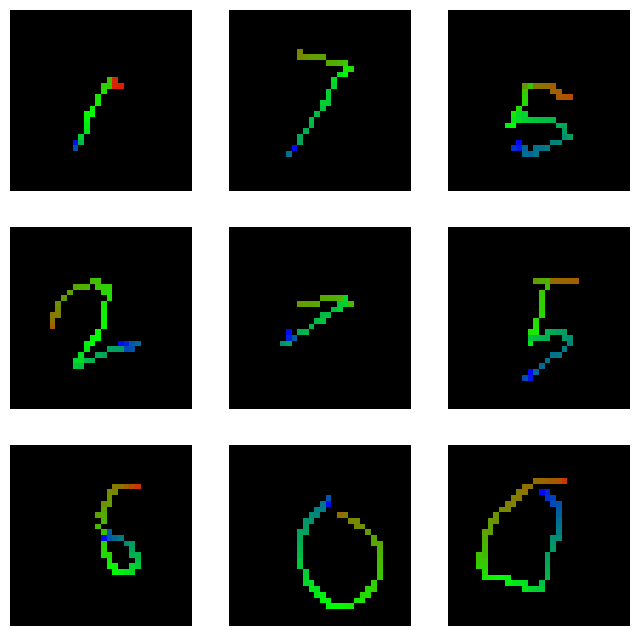

In [10]:
plt.figure(figsize=(8, 8))
for images, labels_batch in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.axis('off')
plt.show()


## 4.2 Architecture Exploration

The coursework asks for **at least 5 different model architectures**.

This final sweep keeps the same baseline data pipeline and adds a few extra medium-capacity architectures specifically to improve coverage inside the `70% to 90%` accuracy band required for the report plot.


In [11]:
ARCHITECTURES = [
    {
        'name': 'tiny_1',
        'conv_layers': [8],
        'kernel_size': 3,
        'dropout': 0.20,
        'epochs': 30,
    },
    {
        'name': 'tiny_2',
        'conv_layers': [8, 16],
        'kernel_size': 3,
        'dropout': 0.25,
        'epochs': 30,
    },
    {
        'name': 'mid_12_24',
        'conv_layers': [12, 24],
        'kernel_size': 3,
        'dropout': 0.28,
        'epochs': 24,
    },
    {
        'name': 'mid_16_24',
        'conv_layers': [16, 24],
        'kernel_size': 3,
        'dropout': 0.30,
        'epochs': 24,
    },
    {
        'name': 'mid_14_28',
        'conv_layers': [14, 28],
        'kernel_size': 3,
        'dropout': 0.31,
        'epochs': 20,
    },
    {
        'name': 'mid_16_24_24',
        'conv_layers': [16, 24, 24],
        'kernel_size': 3,
        'dropout': 0.34,
        'epochs': 16,
    },
    {
        'name': 'mid_14_24_24',
        'conv_layers': [14, 24, 24],
        'kernel_size': 3,
        'dropout': 0.35,
        'epochs': 16,
    },
    {
        'name': 'small_3',
        'conv_layers': [16, 16, 24],
        'kernel_size': 3,
        'dropout': 0.30,
        'epochs': 20,
    },
    {
        'name': 'baseline_cnn',
        'conv_layers': [16, 32, 32],
        'kernel_size': 3,
        'dropout': 0.50,
        'epochs': 18,
    },
    {
        'name': 'mid_kernel5',
        'conv_layers': [12, 24],
        'kernel_size': 5,
        'dropout': 0.30,
        'epochs': 20,
    },
    {
        'name': 'mid_wide',
        'conv_layers': [16, 24, 32],
        'kernel_size': 3,
        'dropout': 0.35,
        'epochs': 18,
    },
    {
        'name': 'deep_4',
        'conv_layers': [16, 24, 32, 32],
        'kernel_size': 3,
        'dropout': 0.35,
        'epochs': 16,
    },
]

pd.DataFrame(ARCHITECTURES)


,name,conv_layers,kernel_size,dropout,epochs
0,tiny_1,[8],3,0.20,30
1,tiny_2,"[8, 16]",3,0.25,30
2,mid_12_24,"[12, 24]",3,0.28,24
3,mid_16_24,"[16, 24]",3,0.30,24
4,mid_14_28,"[14, 28]",3,0.31,20
5,mid_16_24_24,"[16, 24, 24]",3,0.34,16
6,mid_14_24_24,"[14, 24, 24]",3,0.35,16
7,small_3,"[16, 16, 24]",3,0.30,20
8,baseline_cnn,"[16, 32, 32]",3,0.50,18
9,mid_kernel5,"[12, 24]",5,0.30,20


In [12]:
def make_model(config, input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3), num_classes=NUM_GESTURES):
    inputs = keras.Input(shape=input_shape)
    x = layers.Rescaling(1.0 / 255)(inputs)

    for filters in config['conv_layers']:
        x = layers.Conv2D(filters, config['kernel_size'], strides=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.Dropout(config['dropout'])(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(config['dropout'])(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name=config['name'])

sample_model = make_model(ARCHITECTURES[0])
sample_model.summary()


Model: "tiny_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346 (1.35 KB)

 Trainable params: 330 (1.29 KB)

 Non-trainable params: 16 (64.00 B)

In [13]:
def representative_dataset():
    for filename in glob.glob(str(TEST_DIR / '*/*.png')):
        img = keras.preprocessing.image.load_img(filename, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
        img_array = keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        yield [img_array]


def predict_tflite_batch(tflite_model, images_batch):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    outputs = []
    for img_array in images_batch:
        img_array = np.expand_dims(img_array, axis=0)
        input_scale, input_zero_point = input_details['quantization']
        if (input_scale, input_zero_point) != (0.0, 0):
            img_array = np.multiply(img_array, 1.0 / input_scale) + input_zero_point
            img_array = img_array.astype(input_details['dtype'])

        interpreter.set_tensor(input_details['index'], img_array)
        interpreter.invoke()
        pred = interpreter.get_tensor(output_details['index'])[0]

        output_scale, output_zero_point = output_details['quantization']
        if (output_scale, output_zero_point) != (0.0, 0):
            pred = pred.astype(np.float32)
            pred = np.multiply((pred - output_zero_point), output_scale)
        outputs.append(pred)

    return np.array(outputs)


def evaluate_quantized_tflite(tflite_model, dataset):
    correct = 0
    total = 0
    for images_batch, labels_batch in dataset:
        preds = predict_tflite_batch(tflite_model, images_batch.numpy())
        pred_idx = np.argmax(preds, axis=1)
        true_idx = np.argmax(labels_batch.numpy(), axis=1)
        correct += np.sum(pred_idx == true_idx)
        total += len(true_idx)
    return float(correct / total)


def export_c_array(tflite_path, cc_path, variable_name='g_magic_wand_model_data'):
    !xxd -i {tflite_path} > {cc_path}
    replace_text = str(tflite_path).replace('/', '_').replace('.', '_')
    cc_text = Path(cc_path).read_text()
    cc_text = cc_text.replace(replace_text, variable_name)
    Path(cc_path).write_text(cc_text)


In [14]:
all_results = []

for config in ARCHITECTURES:
    print()
    print('=' * 80)
    print('Training architecture:', config['name'])
    print(config)

    keras.backend.clear_session()
    model = make_model(config)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy'],
    )

    checkpoint_path = CHKPT_DIR / f"{config['name']}.keras"
    callbacks = [
        keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max'),
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ]

    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=config.get('epochs', 30),
        callbacks=callbacks,
        verbose=1,
    )

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    keras_path = MODELS_DIR / f"{config['name']}.keras"
    float_tfl_path = MODELS_DIR / f"{config['name']}_float.tflite"
    quant_tfl_path = MODELS_DIR / f"{config['name']}_quant.tflite"
    cc_path = MODELS_DIR / f"{config['name']}.cc"

    model.save(keras_path)

    float_converter = tf.lite.TFLiteConverter.from_keras_model(model)
    float_tflite_model = float_converter.convert()
    with open(float_tfl_path, 'wb') as f:
        f.write(float_tflite_model)

    quant_converter = tf.lite.TFLiteConverter.from_keras_model(model)
    quant_converter.optimizations = [tf.lite.Optimize.DEFAULT]
    quant_converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    quant_converter.inference_input_type = tf.int8
    quant_converter.inference_output_type = tf.int8
    quant_converter.representative_dataset = representative_dataset
    quant_tflite_model = quant_converter.convert()
    with open(quant_tfl_path, 'wb') as f:
        f.write(quant_tflite_model)

    export_c_array(quant_tfl_path, cc_path)

    quant_test_accuracy = evaluate_quantized_tflite(quant_tflite_model, test_ds)

    row = {
        'model_name': config['name'],
        'conv_layers': '-'.join(map(str, config['conv_layers'])),
        'kernel_size': config['kernel_size'],
        'dropout': config['dropout'],
        'epochs_run': config.get('epochs', 30),
        'keras_test_accuracy_pct': round(test_accuracy * 100, 2),
        'quant_tflite_test_accuracy_pct': round(quant_test_accuracy * 100, 2),
        'keras_size_bytes': os.path.getsize(keras_path),
        'float_tflite_size_bytes': os.path.getsize(float_tfl_path),
        'quant_tflite_size_bytes': os.path.getsize(quant_tfl_path),
        'cc_size_bytes': os.path.getsize(cc_path),
        'best_val_accuracy_pct': round(max(history.history['val_accuracy']) * 100, 2),
    }
    all_results.append(row)

results_df = pd.DataFrame(all_results).sort_values(by='quant_tflite_size_bytes')
results_df.to_csv(RESULTS_DIR / 'architecture_results.csv', index=False)
results_df



Training architecture: tiny_1
{'name': 'tiny_1', 'conv_layers': [8], 'kernel_size': 3, 'dropout': 0.2, 'epochs': 30}
Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1044 - loss: 0.5897 - val_accuracy: 0.1100 - val_loss: 0.5272
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1174 - loss: 0.3978 - val_accuracy: 0.1161 - val_loss: 0.3576
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1420 - loss: 0.3386 - val_accuracy: 0.1397 - val_loss: 0.3259
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1470 - loss: 0.3307 - val_accuracy: 0.1758 - val_loss: 0.3205
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1588 - loss: 0.3284 - val_accuracy: 0.1870 - val_loss: 0.3181
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1633 - loss: 0.3264 - val_accuracy: 0.1652 - val_loss: 0.3170
Epoch 7/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.1770 - loss: 0.3240 - val_accuracy: 0.180

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Training architecture: tiny_2
{'name': 'tiny_2', 'conv_layers': [8, 16], 'kernel_size': 3, 'dropout': 0.25, 'epochs': 30}
Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.1242 - loss: 0.5513 - val_accuracy: 0.1052 - val_loss: 0.4596
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.1564 - loss: 0.3484 - val_accuracy: 0.1600 - val_loss: 0.3410
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1808 - loss: 0.3240 - val_accuracy: 0.2330 - val_loss: 0.3160
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.2138 - loss: 0.3153 - val_accuracy: 0.3645 - val_loss: 0.3068
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.2733 - loss: 0.3061 - val_accuracy: 0.0961 - val_loss: 0.3091
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2989 - loss: 0.2975 - val_accuracy: 0.4242 - val_loss: 0.2850
Epoch 7/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3352 - loss: 0.2882 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Training architecture: mid_12_24
{'name': 'mid_12_24', 'conv_layers': [12, 24], 'kernel_size': 3, 'dropout': 0.28, 'epochs': 24}
Epoch 1/24
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.0994 - loss: 0.4587 - val_accuracy: 0.0800 - val_loss: 0.4439
Epoch 2/24
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.1532 - loss: 0.3270 - val_accuracy: 0.1612 - val_loss: 0.3498
Epoch 3/24
207/207 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.2336 - loss: 0.3121 - val_accuracy: 0.2491 - val_loss: 0.3082
Epoch 4/24
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.3032 - loss: 0.2974 - val_accuracy: 0.4373 - val_loss: 0.2865
Epoch 5/24
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.3641 - loss: 0.2830 - val_accuracy: 0.4503 - val_loss: 0.2722
Epoch 6/24
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4017 - loss: 0.2704 - val_accuracy: 0.4924 - val_loss: 0.2546
Epoch 7/24
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.4365 - loss: 0.2599 - val_acc

...


Training architecture: mid_wide
{'name': 'mid_wide', 'conv_layers': [16, 24, 32], 'kernel_size': 3, 'dropout': 0.35, 'epochs': 18}
Epoch 1/18
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.1185 - loss: 0.4086 - val_accuracy: 0.0973 - val_loss: 0.3928
Epoch 2/18
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.2153 - loss: 0.3170 - val_accuracy: 0.1033 - val_loss: 0.3382
Epoch 3/18
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3098 - loss: 0.2911 - val_accuracy: 0.3788 - val_loss: 0.2759
Epoch 4/18
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.3767 - loss: 0.2705 - val_accuracy: 0.6333 - val_loss: 0.2431
Epoch 5/18
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4500 - loss: 0.2504 - val_accuracy: 0.6567 - val_loss: 0.2212
Epoch 6/18
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5033 - loss: 0.2341 - val_accuracy: 0.7852 - val_loss: 0.2025
Epoch 7/18
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.5556 - loss: 0.2184 - val_

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Training architecture: deep_4
{'name': 'deep_4', 'conv_layers': [16, 24, 32, 32], 'kernel_size': 3, 'dropout': 0.35, 'epochs': 16}
Epoch 1/16
207/207 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.1712 - loss: 0.4467 - val_accuracy: 0.1033 - val_loss: 0.3396
Epoch 2/16
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.3427 - loss: 0.2887 - val_accuracy: 0.1312 - val_loss: 0.3027
Epoch 3/16
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.4915 - loss: 0.2425 - val_accuracy: 0.7236 - val_loss: 0.1867
Epoch 4/16
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.6208 - loss: 0.1986 - val_accuracy: 0.8612 - val_loss: 0.1306
Epoch 5/16
207/207 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.7026 - loss: 0.1684 - val_accuracy: 0.9130 - val_loss: 0.1006
Epoch 6/16
207/207 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7402 - loss: 0.1505 - val_accuracy: 0.9300 - val_loss: 0.0841
Epoch 7/16
207/207 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7815 - loss: 0.1327 - val_

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model_name,conv_layers,kernel_size,dropout,epochs_run,keras_test_accuracy_pct,quant_tflite_test_accuracy_pct,keras_size_bytes,float_tflite_size_bytes,quant_tflite_size_bytes,cc_size_bytes,best_val_accuracy_pct
0,tiny_1,8,3,0.20,30,41.64,42.27,45272,3588,3272,20273,37.79
1,tiny_2,8-16,3,0.25,30,75.27,74.09,77204,9084,5536,34235,76.64
2,mid_12_24,12-24,3,0.28,24,83.09,81.00,97278,15700,7544,46617,80.85
3,mid_16_24,16-24,3,0.30,24,71.64,73.00,109115,19604,8624,53277,70.64
4,mid_14_28,14-28,3,0.31,20,72.00,71.64,109902,19844,8744,54017,73.36
7,small_3,16-16-24,3,0.30,20,93.27,93.00,153686,29356,11952,73800,93.06
9,mid_kernel5,12-24,5,0.30,20,94.73,94.82,159485,36472,12760,78784,95.67
6,mid_14_24_24,14-24-24,3,0.35,16,88.27,87.18,182687,39080,14608,90180,89.58
5,mid_16_24_24,16-24-24,3,0.34,16,97.55,97.45,188607,41032,15152,93534,96.12
10,mid_wide,16-24-32,3,0.35,18,94.27,94.36,210651,48200,17120,105670,95.06


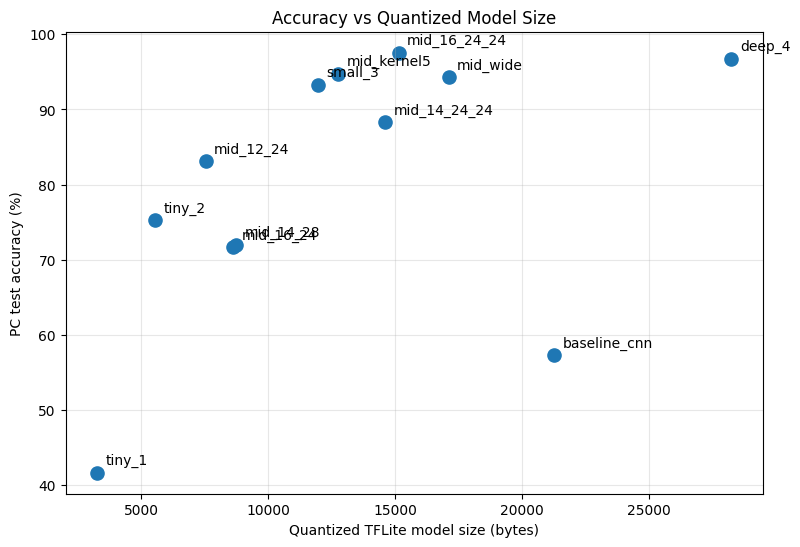

In [15]:
plt.figure(figsize=(9, 6))
plt.scatter(results_df['quant_tflite_size_bytes'], results_df['keras_test_accuracy_pct'], s=90)

for _, row in results_df.iterrows():
    plt.annotate(
        row['model_name'],
        (row['quant_tflite_size_bytes'], row['keras_test_accuracy_pct']),
        textcoords='offset points',
        xytext=(6, 6),
    )

plt.xlabel('Quantized TFLite model size (bytes)')
plt.ylabel('PC test accuracy (%)')
plt.title('Accuracy vs Quantized Model Size')
plt.grid(alpha=0.3)
plt.show()


In [16]:
target_range_df = results_df[
    (results_df['keras_test_accuracy_pct'] >= 70) &
    (results_df['keras_test_accuracy_pct'] <= 90)
].copy()

print('Models already inside the coursework target accuracy range (70% to 90%):')
display(target_range_df)

print('Count in target band:', len(target_range_df))
print('Suggested report set: choose 5 models spanning from the smallest valid model to the largest valid model in this band.')


Models already inside the coursework target accuracy range (70% to 90%):


,model_name,conv_layers,kernel_size,dropout,epochs_run,keras_test_accuracy_pct,quant_tflite_test_accuracy_pct,keras_size_bytes,float_tflite_size_bytes,quant_tflite_size_bytes,cc_size_bytes,best_val_accuracy_pct
1,tiny_2,8-16,3,0.25,30,75.27,74.09,77204,9084,5536,34235,76.64
2,mid_12_24,12-24,3,0.28,24,83.09,81.00,97278,15700,7544,46617,80.85
3,mid_16_24,16-24,3,0.30,24,71.64,73.00,109115,19604,8624,53277,70.64
4,mid_14_28,14-28,3,0.31,20,72.00,71.64,109902,19844,8744,54017,73.36
6,mid_14_24_24,14-24-24,3,0.35,16,88.27,87.18,182687,39080,14608,90180,89.58


Count in target band: 5
Suggested report set: choose 5 models spanning from the smallest valid model to the largest valid model in this band.


## Export Results

The next cell downloads the architecture summary CSV so it can be reused in the report.


In [17]:
files.download(str(RESULTS_DIR / 'architecture_results.csv'))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## MCU Latency Measurements

The coursework also asks for `accuracy vs latency on the MCU`.

That part must be measured on the Arduino Nano 33 BLE Sense. The workflow is:

1. Pick 5 or more exported `.cc` models from `/content/dc2_4_1_4_2/models`.
2. Insert each model into the Arduino `magic_wand` example one at a time.
3. Add `micros()` timing around `interpreter->Invoke()`.
4. Record repeated latency values from the serial monitor.
5. Fill them into the table below and then plot `accuracy vs latency`.


In [18]:
latency_template_df = results_df[[
    'model_name',
    'keras_test_accuracy_pct',
    'quant_tflite_test_accuracy_pct',
    'quant_tflite_size_bytes',
]].copy()
latency_template_df['latency_us_avg'] = np.nan
latency_template_df['latency_us_min'] = np.nan
latency_template_df['latency_us_max'] = np.nan
latency_template_df['notes'] = ''
latency_template_df


,model_name,keras_test_accuracy_pct,quant_tflite_test_accuracy_pct,quant_tflite_size_bytes,latency_us_avg,latency_us_min,latency_us_max,notes
0,tiny_1,41.64,42.27,3272,NaN,NaN,NaN,
1,tiny_2,75.27,74.09,5536,NaN,NaN,NaN,
2,mid_12_24,83.09,81.00,7544,NaN,NaN,NaN,
3,mid_16_24,71.64,73.00,8624,NaN,NaN,NaN,
4,mid_14_28,72.00,71.64,8744,NaN,NaN,NaN,
7,small_3,93.27,93.00,11952,NaN,NaN,NaN,
9,mid_kernel5,94.73,94.82,12760,NaN,NaN,NaN,
6,mid_14_24_24,88.27,87.18,14608,NaN,NaN,NaN,
5,mid_16_24_24,97.55,97.45,15152,NaN,NaN,NaN,
10,mid_wide,94.27,94.36,17120,NaN,NaN,NaN,


## Arduino Timing Snippet

Add this logic around the inference call in the Arduino `magic_wand` example:

```cpp
unsigned long start_time_micros = micros();
TfLiteStatus invoke_status = interpreter->Invoke();
unsigned long end_time_micros = micros();
unsigned long inference_latency_micros = end_time_micros - start_time_micros;
Serial.print("Latency: ");
Serial.print(inference_latency_micros);
Serial.println(" us");
```

Once you have measured the board-side latency values, come back and fill them into the table or CSV template.


## Notes for the Report

For task `4.2`, the report should include:
- a plot of `accuracy vs model size`
- a plot of `accuracy vs MCU latency`
- a short explanation of the trade-off trend

A useful discussion angle is:
- smaller models usually reduce memory footprint and MCU latency
- but too-small models may lose representational capacity and reduce accuracy
- widening or deepening the network may improve accuracy, but it increases model size and often raises latency
